# Step 3-1 (B) : GDELT + HMM Regime — XGBoost Walk-Forward

> **목적**: 기존 Step3A(자산별 특성 + 거시지표) 베이스라인에
> GDELT 감성 피처 3개와 HMM 레짐 확률 1개를 추가하여  
> XGBoost Walk-Forward의 OOS IC를 개선하고 Q, Ω를 재산출한다.

---

## 설계 개요

```
[GDELT GKG]      → fin_sentiment, article_count
[GDELT EVENTS]   → min_shock
[FRED + yfinance] → VIX, HY_spread, yield_curve, Sahm, (MOVE)
         ↓
   HMM (K=3, full covariance, p=7)
   regime ∈ {0:안정, 1:중립, 2:위기}
         ↓
   XGBoost Walk-Forward (IS=150일 / Embargo=21일 / OOS=21일)
   피처: 자산별 특성(11) + 거시지표(17) + GDELT(3) + HMM(1) = 32개 수치
         ↓
   Q, Ω → Black-Litterman (Step4)
```

### GDELT 수집 전략 (캐시 우선)

| 단계 | 방법 | 이유 |
|------|------|------|
| 최초 1회 | BigQuery → `data/gdelt_gkg_cache.parquet` / `data/gdelt_events_cache.parquet` 저장 | 10년치 GKG 스캔은 수 TB → 반복 실행 시 무료 한도(1TB/월) 초과 위험 |
| 이후 실행 | 캐시 parquet 로드 | BigQuery 쿼리 비용 0 |

> `FORCE_REBUILD = False` (기본값) → 캐시 파일이 있으면 BigQuery를 호출하지 않음  
> 쿼리를 수정해야 할 때만 `FORCE_REBUILD = True` 로 변경 후 1회 실행

### 피처 배분 (decision_log 17-3 기준)

| 그룹 | 피처 | HMM 입력 | XGBoost 입력 |
|------|------|:---:|:---:|
| A. 주식시장 공포 | VIX_level | ✅ | ✅ (MACRO) |
| B. 신용 | HY_spread | ✅ | ✅ (MACRO) |
| C. 금리·경기 | yield_curve, MOVE_index | ✅ | ✅ (MACRO) |
| D. 실물 | sahm_indicator | ✅ | ✅ (MACRO) |
| E. GDELT 감성 | fin_sentiment | ✅ | ✅ (GDELT) |
| E. GDELT 볼륨 | article_count | ✅ | ✅ (GDELT) |
| F. GDELT 충격 | min_shock | ❌ | ✅ (GDELT) |
| G. HMM 출력 | hmm_crisis_prob | — | ✅ (HMM) |

## 1. 라이브러리 임포트 및 설정

In [10]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# HMM
try:
    from hmmlearn.hmm import GaussianHMM
    HMM_AVAILABLE = True
    print("hmmlearn 사용 가능")
except ImportError:
    HMM_AVAILABLE = False
    print("⚠️ hmmlearn 미설치 → uv add hmmlearn 실행 후 재시작")

# GDELT DOC API (BigQuery 대신 무료 REST API 사용)
import requests
import time

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
from scipy.stats import spearmanr

import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("outputs/step3b")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Walk-Forward 파라미터 ─────────────────────────────────────────────────────
IS_DAYS         = 150
EMBARGO_DAYS    = 21
OOS_DAYS        = 21
N_CLASSES       = 5
N_OPTUNA_TRIALS = 30
RANDOM_STATE    = 42

# ── GDELT 수집 제어 ────────────────────────────────────────────────────────────
# False(기본) → 캐시 있으면 API 호출 안 함 (재실행 비용 0)
# True        → 강제 재수집 (쿼리 수정 시에만 사용)
FORCE_REBUILD = False
START_DATE    = "2016-01-01"
END_DATE      = "2025-12-31"

print("\n✅ 설정 완료  (BigQuery 없음 → GDELT DOC API v2 사용)")
print(f"  IS={IS_DAYS}일 | Embargo={EMBARGO_DAYS}일 | OOS={OOS_DAYS}일")
print(f"  FORCE_REBUILD={FORCE_REBUILD}  ← True 시 DOC API 재호출")

hmmlearn 사용 가능

✅ 설정 완료  (BigQuery 없음 → GDELT DOC API v2 사용)
  IS=150일 | Embargo=21일 | OOS=21일
  FORCE_REBUILD=False  ← True 시 DOC API 재호출


## 2. 기존 패널 로드 (Step2 산출물)

`long_panel.parquet` 또는 `df_panel.csv` 로드.  
이 패널에 GDELT + HMM 컬럼을 추가하여 최종 학습 데이터를 만든다.

In [11]:
try:
    panel = pd.read_parquet(DATA_DIR / "long_panel.parquet")
    print("✅ parquet 로드 성공")
except FileNotFoundError:
    panel = pd.read_csv(DATA_DIR / "df_panel.csv", parse_dates=["Date"])
    panel = panel.rename(columns={"Date": "date", "Ticker": "ticker"})
    panel = panel.set_index(["date", "ticker"])
    print("✅ csv 로드 성공")

panel = panel.sort_index()

# 날짜를 DatetimeIndex로 보장
dates_level = panel.index.get_level_values("date")
if not isinstance(dates_level, pd.DatetimeIndex):
    panel.index = panel.index.set_levels(
        pd.to_datetime(panel.index.levels[0]), level=0
    )

print(f"Panel shape : {panel.shape}")
print(f"날짜 범위   : {panel.index.get_level_values('date').min().date()} "
      f"~ {panel.index.get_level_values('date').max().date()}")
print(f"ETF 수      : {panel.index.get_level_values('ticker').nunique()}")

✅ csv 로드 성공
Panel shape : (51612, 36)
날짜 범위   : 2017-01-04 ~ 2025-12-31
ETF 수      : 22


## 3. GDELT 수집 (BigQuery → 캐시 우선)

### 수집 대상

| 테이블 | 피처 | 설명 |
|--------|------|------|
| GKG | `fin_sentiment` | GCAM c15 금융 감성 (긍정 - 부정), 일별 평균 |
| GKG | `article_count` | 경제/금융 테마 일별 기사 수 |
| EVENTS | `min_shock` | MIN(GoldsteinScale) — 당일 최극단 사건 충격 |

### 캐시 전략
```
data/gdelt_gkg_cache.parquet    ← GKG 쿼리 결과 (1회 저장)
data/gdelt_events_cache.parquet ← EVENTS 쿼리 결과 (1회 저장)
```
두 파일이 모두 존재하면 BigQuery를 호출하지 않는다 (`FORCE_REBUILD=False`).

In [ ]:
import os
import pandas as pd
import numpy as np
from google.cloud import bigquery
from pathlib import Path

# ── 1. 설정 ───────────────────────────────────────────────────────────────────
BQ_PROJECT_ID = "finance-data-analysis-493308"
DATA_DIR      = Path("./data")
CACHE_DIR     = DATA_DIR / "gdelt_cache"   # 월별 캐시 디렉토리 (기존 단일 파일 → 월별 분할)
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

START_DATE    = "2016-01-01"
END_DATE      = "2025-12-31"
FORCE_REBUILD = False     # True: 특정 달 강제 재수집 (쿼리 수정 시에만)
BQ_AVAILABLE  = True

# ── 2. 쿼리 정의 ──────────────────────────────────────────────────────────────
# GKG: gkg_partitioned + _PARTITIONTIME 필터 (스캔 비용 최소화)
#   Themes 7개 확장:
#     기존 4개: ECON_STOCKMARKET, ECON_FRBRESERVE, ECON_INFLATION, ECON_UNEMPLOYMENT
#     추가 3개: ECON_RECESSION(경기침체 직접 언급), ECON_TRADE(2018 관세전쟁),
#               ECON_BANKING(2023 SVB 등 은행 위기)
#   SourceCommonName: REGEXP_CONTAINS → 서브도메인 불일치 방지
# EVENTS: ActionGeo_CountryCode='US' (사건 발생 지역 기준)
#          → Actor1='USA' 대비 외국발 미국충격(중국발 관세 등)도 포착
#          IsRootEvent=1 유지 (중복 방지, MIN에는 결과 영향 없음)
#          EventCode 필터 없음 (CAMEO 코드 체계상 경제 이벤트가 명확히 분리 안 됨)

GKG_QUERY = """
SELECT
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(DATE AS STRING), 1, 8)) AS date,
    AVG(
        COALESCE(SAFE_CAST(REGEXP_EXTRACT(GCAM, r'c15\\.1:([0-9.]+)') AS FLOAT64), 0.0)
      - COALESCE(SAFE_CAST(REGEXP_EXTRACT(GCAM, r'c15\\.2:([0-9.]+)') AS FLOAT64), 0.0)
    ) AS fin_sentiment,
    COUNT(*) AS article_count
FROM `gdelt-bq.gdeltv2.gkg_partitioned`
WHERE _PARTITIONTIME BETWEEN TIMESTAMP('{start_dash}') AND TIMESTAMP('{end_dash}')
    AND REGEXP_CONTAINS(Themes,
        r'(ECON_STOCKMARKET|ECON_FRBRESERVE|ECON_INFLATION|ECON_UNEMPLOYMENT|ECON_RECESSION|ECON_TRADE|ECON_BANKING)')
    AND REGEXP_CONTAINS(SourceCommonName, r'(reuters|cnbc|wsj|ft|bloomberg)')
GROUP BY date
ORDER BY date
"""

EVENTS_QUERY = """
SELECT
    PARSE_DATE('%Y%m%d', CAST(SQLDATE AS STRING)) AS date,
    MIN(GoldsteinScale) AS min_shock
FROM `gdelt-bq.gdeltv2.events_partitioned`
WHERE _PARTITIONTIME BETWEEN TIMESTAMP('{start_dash}') AND TIMESTAMP('{end_dash}')
    AND ActionGeo_CountryCode = 'US'
    AND IsRootEvent = 1
GROUP BY date
ORDER BY date
"""

# ── 3. 월별 캐시 헬퍼 ────────────────────────────────────────────────────────
# 파일 명명 규칙: gdelt_cache/gkg_YYYY_MM.parquet
#                gdelt_cache/events_YYYY_MM.parquet
# → 새 GCP 프로젝트로 실행해도 기존 캐시는 자동 스킵

def cached_months() -> set:
    """이미 수집 완료된 (year, month) 집합 — gkg_YYYY_MM.parquet 기준"""
    result = set()
    for f in CACHE_DIR.glob("gkg_????_??.parquet"):
        parts = f.stem.split("_")   # ['gkg', 'YYYY', 'MM']
        result.add((int(parts[1]), int(parts[2])))
    return result

def month_cache_path(prefix: str, year: int, month: int) -> Path:
    return CACHE_DIR / f"{prefix}_{year}_{month:02d}.parquet"

def load_all_cached() -> tuple:
    """월별 캐시 전체 병합 → (gkg_df, events_df)"""
    gkg_parts, evt_parts = [], []
    for f in sorted(CACHE_DIR.glob("gkg_????_??.parquet")):
        parts = f.stem.split("_")
        y, m  = int(parts[1]), int(parts[2])
        gkg_parts.append(pd.read_parquet(f))
        evt_path = month_cache_path("events", y, m)
        if evt_path.exists():
            evt_parts.append(pd.read_parquet(evt_path))

    if not gkg_parts:
        return None, None

    gkg  = pd.concat(gkg_parts).set_index("date").sort_index()
    evts = pd.concat(evt_parts).set_index("date").sort_index() if evt_parts else pd.DataFrame()
    gkg  = gkg[~gkg.index.duplicated(keep="first")]
    evts = evts[~evts.index.duplicated(keep="first")] if not evts.empty else evts
    return gkg, evts

# ── 4. 수집 메인 로직 ─────────────────────────────────────────────────────────
gkg_df    = None
events_df = None

already_cached = cached_months()

# 전체 범위 월 목록 (역순: 최신→과거) 중 아직 캐시 없는 달만 수집
all_months = pd.date_range(START_DATE, END_DATE, freq="MS").sort_values(ascending=False)
to_collect = [m for m in all_months
              if FORCE_REBUILD or (m.year, m.month) not in already_cached]

if not to_collect:
    print("✅ 모든 달 캐시 완료 → 캐시에서 로드")
    gkg_df, events_df = load_all_cached()

elif BQ_AVAILABLE:
    print(f"🚀 BigQuery 수집 시작  (Project: {BQ_PROJECT_ID})")
    print(f"   수집 대상 : {len(to_collect):3d}개월  / 전체 {len(all_months)}개월")
    print(f"   이미 캐시 : {len(already_cached):3d}개월  → 해당 달은 자동 스킵")
    client = bigquery.Client(project=BQ_PROJECT_ID)

    total_scanned_gb = 0.0
    MAX_QUOTA_GB     = 950   # 월 1TB 한도 안전 마진

    for start_month in to_collect:
        end_month = start_month + pd.offsets.MonthEnd(0)
        s_dash    = start_month.strftime("%Y-%m-%d")
        e_dash    = end_month.strftime("%Y-%m-%d")
        ym_str    = start_month.strftime("%Y-%m")
        print(f"\n📅 {ym_str} 작업 중...")

        try:
            # Dry Run — 예상 스캔량 확인
            filled_gkg = GKG_QUERY.format(start_dash=s_dash, end_dash=e_dash)
            dry_config = bigquery.QueryJobConfig(dry_run=True)
            dry_job    = client.query(filled_gkg, job_config=dry_config)
            month_gb   = dry_job.total_bytes_processed / (1024 ** 3)

            if total_scanned_gb + month_gb > MAX_QUOTA_GB:
                print(f"⚠️  쿼터 한도 도달 ({total_scanned_gb + month_gb:.1f} GB) → 중단")
                print(f"   💡 다음 실행 시 {ym_str}부터 자동으로 이어서 수집됩니다.")
                break

            print(f"   [Scan: {month_gb:.2f} GB] 수집 중...")
            gkg_month = client.query(filled_gkg).to_dataframe()
            gkg_month.to_parquet(
                month_cache_path("gkg", start_month.year, start_month.month), index=False
            )

            filled_events = EVENTS_QUERY.format(start_dash=s_dash, end_dash=e_dash)
            evt_month     = client.query(filled_events).to_dataframe()
            evt_month.to_parquet(
                month_cache_path("events", start_month.year, start_month.month), index=False
            )

            total_scanned_gb += month_gb
            print(f"   ✅ {ym_str} 저장 완료  (누적: {total_scanned_gb:.1f} GB)")

        except Exception as e:
            print(f"   ❌ {ym_str} 실패: {e}")
            break

    gkg_df, events_df = load_all_cached()

# ── 5. 결과 확인 ─────────────────────────────────────────────────────────────
if gkg_df is not None and not gkg_df.empty:
    print(f"\n✅ GDELT 로드 완료")
    print(f"   GKG    : {gkg_df.shape}  ({gkg_df.index.min().date()} ~ {gkg_df.index.max().date()})")
    if events_df is not None and not events_df.empty:
        print(f"   EVENTS : {events_df.shape}  "
              f"({events_df.index.min().date()} ~ {events_df.index.max().date()})")
    display(gkg_df.head())
else:
    print("❗ 수집된 데이터가 없습니다. 위쪽 에러 메시지를 확인하세요.")

## 4. GDELT 피처 엔지니어링

XGBoost에 투입할 3개 피처 생성:

| 피처 | 계산 | 의미 |
|------|------|------|
| `gdelt_avg_tone_1m` | `fin_sentiment.rolling(21).mean()` | 21일 평균 감성 (단기 레짐 분위기) |
| `gdelt_tone_momentum` | `gdelt_avg_tone_1m.diff(21)` | 감성 추세 가속도 |
| `gdelt_article_volume` | `log1p(article_count) / rolling(63).mean()` | 볼륨 정규화 (스파이크 감지) |
| `min_shock` | 원본 유지 | 당일 최극단 충격 (HMM 제외, XGBoost만) |

In [18]:
gdelt_daily = gkg_df.copy()

# XGBoost 피처
gdelt_daily['gdelt_avg_tone_1m']      = gdelt_daily['fin_sentiment'].rolling(21, min_periods=10).mean()
gdelt_daily['gdelt_tone_momentum']    = gdelt_daily['gdelt_avg_tone_1m'].diff(21)

log_vol = np.log1p(gdelt_daily['article_count'])
roll_mean = log_vol.rolling(63, min_periods=21).mean()
gdelt_daily['gdelt_article_volume']  = (log_vol / roll_mean.replace(0, np.nan)).fillna(1.0)

# min_shock 병합
gdelt_daily['min_shock'] = events_df['min_shock']

# HMM 입력용 정규화 컬럼 (fin_sentiment, article_count → 원본 보존)
gdelt_daily['article_count_norm'] = (
    (gdelt_daily['article_count'] - gdelt_daily['article_count'].rolling(252, min_periods=63).mean())
    / gdelt_daily['article_count'].rolling(252, min_periods=63).std()
).fillna(0.0)

gdelt_daily = gdelt_daily.ffill().fillna(0)

print("GDELT 피처 생성 완료:")
print(gdelt_daily[['fin_sentiment', 'gdelt_avg_tone_1m', 'gdelt_tone_momentum',
                    'gdelt_article_volume', 'min_shock', 'article_count_norm']].describe().round(4))

GDELT 피처 생성 완료:
       fin_sentiment  gdelt_avg_tone_1m  gdelt_tone_momentum  \
count       317.0000           317.0000             317.0000   
mean         -0.0079            -0.0079               0.0005   
std           0.0187             0.0048               0.0059   
min          -0.1500            -0.0189              -0.0153   
25%          -0.0078            -0.0116              -0.0027   
50%           0.0000            -0.0067               0.0005   
75%           0.0000            -0.0036               0.0047   
max           0.0233             0.0000               0.0137   

       gdelt_article_volume  min_shock  article_count_norm  
count                 317.0      317.0               317.0  
mean                 0.9941      -10.0             -0.1827  
std                  0.1382        0.0              0.7793  
min                  0.5555      -10.0             -1.8082  
25%                  0.8529      -10.0             -0.5284  
50%                  1.0594      -10.0   

## 5. HMM 레짐 학습 (K=3)

### 설계 원칙 (decision_log 17-3 / Step2_Step3_검토_및_설계_보완.md)

- **K=3**: stable(0), neutral(1), crisis(2)
- **covariance_type='full'**: 피처 간 상관관계 포착 (진단행렬 사용 시 VIX-HY 동시폭발 패턴 놓침)
- **p≤7 제약**: 위기 레짐 유효 비율 ≥ 5:1 보장
  - p=7 → 위기 파라미터 35개, 250거래일/35 = 7.1:1 ✅
- **학습 범위**: 전체 시계열 1회 (재보정: 매년 1월 또는 KL-divergence 트리거)

### HMM 입력 피처 (p=7)

| 그룹 | 피처 | 출처 |
|------|------|------|
| 주식시장 공포 | VIX_level | yfinance |
| 신용·유동성 | HY_spread | FRED |
| 금리·경기 | yield_curve | FRED |
| 채권 변동성 | TYVIX (CBOE 10Y 국채 내재변동성) | yfinance — MOVE 대체 |
| 실물 경기 | sahm_indicator | FRED |
| GDELT 감성 | fin_sentiment | GKG |
| GDELT 볼륨 | article_count_norm | GKG |

> **TYVIX 선택 이유**: ICE MOVE Index는 FRED 미제공 (독점 데이터).
> CBOE TYVIX(^TYVIX)는 동일한 10년 국채 옵션 내재변동성을 측정하며 MOVE와 상관관계 0.85~0.90.
> 2022년 금리인상 레짐처럼 VIX는 낮은데 채권 변동성이 폭등하는 구간을 포착하려면 필수.
> yfinance 수집 실패 시 TLT 실현변동성(rolling std × √252 × 100)으로 자동 대체.

In [ ]:
# ── 패널에서 날짜별 거시지표 추출 ─────────────────────────────────────────────
# 거시지표는 모든 ticker에서 동일 → 첫 번째 ticker 슬라이스 사용
first_ticker = panel.index.get_level_values('ticker').unique()[0]
macro_ts = panel.xs(first_ticker, level='ticker')[[
    'VIX_level', 'HY_spread', 'yield_curve', 'sahm_indicator'
]].copy()

# ── TYVIX (채권 변동성 지수) — yfinance 수집, 실패 시 TLT 실현변동성 대체 ─────
# MOVE(ICE)는 FRED 미제공 → CBOE TYVIX(^TYVIX)로 대체
# TYVIX: 10년 국채 옵션 내재변동성
#   2022 금리인상 레짐: VIX ~35 vs TYVIX/MOVE ~160 → 채권 위기 주도 구간 포착에 필수
TYVIX_CACHE     = DATA_DIR / "tyvix_index.parquet"
tyvix_available = False

if TYVIX_CACHE.exists():
    tyvix_ts        = pd.read_parquet(TYVIX_CACHE)['TYVIX']
    tyvix_available = True
    print(f"✅ TYVIX 로드: {tyvix_ts.shape[0]}행")
else:
    import yfinance as yf
    for ticker in ['^TYVIX', 'VXTYN', '^VXTYN']:
        try:
            raw = yf.download(ticker, start=START_DATE, end=END_DATE,
                              auto_adjust=True, progress=False)
            if len(raw) > 100:
                tyvix_ts        = raw['Close'].squeeze().rename('TYVIX')
                tyvix_ts        = tyvix_ts.reindex(macro_ts.index, method='ffill')
                pd.DataFrame({'TYVIX': tyvix_ts}).to_parquet(TYVIX_CACHE)
                tyvix_available = True
                print(f"✅ TYVIX ({ticker}) 수집 완료: {len(tyvix_ts)}행")
                break
        except Exception:
            continue

    if not tyvix_available:
        # TLT 실현변동성 proxy (연율화 ×100 → TYVIX 스케일 근사)
        try:
            tlt_ret  = panel.xs('TLT', level='ticker')['ret_1m']
            tyvix_ts = (tlt_ret.rolling(21).std() * np.sqrt(252) * 100).rename('TYVIX')
            tyvix_ts = tyvix_ts.reindex(macro_ts.index, method='ffill')
            pd.DataFrame({'TYVIX': tyvix_ts}).to_parquet(TYVIX_CACHE)
            tyvix_available = True
            print(f"✅ TLT 변동성 proxy 생성 (TYVIX 대체): {len(tyvix_ts)}행")
        except Exception as e:
            print(f"⚠️ TYVIX 수집 실패 ({e}) → p=6으로 HMM 실행 (위기 비율: 250/30 = 8.3:1 ✅)")

# ── HMM 입력 데이터 구성 ─────────────────────────────────────────────────────
hmm_input = macro_ts.copy()
hmm_input['fin_sentiment']      = gdelt_daily['fin_sentiment'].reindex(hmm_input.index, method='ffill')
hmm_input['article_count_norm'] = gdelt_daily['article_count_norm'].reindex(hmm_input.index, method='ffill')

if tyvix_available:
    hmm_input['TYVIX']   = tyvix_ts
    hmm_feature_cols     = ['VIX_level', 'HY_spread', 'yield_curve', 'sahm_indicator',
                             'TYVIX', 'fin_sentiment', 'article_count_norm']
    print(f"HMM 입력 피처: p=7 (TYVIX 포함)")
else:
    hmm_feature_cols     = ['VIX_level', 'HY_spread', 'yield_curve', 'sahm_indicator',
                             'fin_sentiment', 'article_count_norm']
    print(f"HMM 입력 피처: p=6 (TYVIX 제외)")

hmm_input = hmm_input[hmm_feature_cols].ffill().dropna()
print(f"HMM 학습 데이터: {hmm_input.shape} "
      f"({hmm_input.index.min().date()} ~ {hmm_input.index.max().date()})")

In [20]:
HMM_CACHE = DATA_DIR / "hmm_regime.parquet"

if not FORCE_REBUILD and HMM_CACHE.exists():
    regime_df = pd.read_parquet(HMM_CACHE)
    print(f"✅ HMM 레짐 캐시 로드: {regime_df.shape}")

elif HMM_AVAILABLE:
    # ── 표준화 ──────────────────────────────────────────────────────────────
    scaler   = StandardScaler()
    X_hmm    = scaler.fit_transform(hmm_input.values)  # (T, p)

    # ── HMM 학습 ────────────────────────────────────────────────────────────
    # n_iter=200: full covariance + p=7 수렴에 충분한 EM 반복 횟수
    hmm_model = GaussianHMM(
        n_components=3,
        covariance_type='full',
        n_iter=200,
        tol=1e-4,
        random_state=RANDOM_STATE,
    )
    hmm_model.fit(X_hmm)
    print(f"HMM 학습 완료 (수렴: {hmm_model.monitor_.converged})")

    # ── 상태 시퀀스 및 확률 ─────────────────────────────────────────────────
    states      = hmm_model.predict(X_hmm)           # (T,) 0/1/2
    state_proba = hmm_model.predict_proba(X_hmm)     # (T, 3)

    # ── 레짐 의미 부여: VIX_level 평균으로 0=안정 / 1=중립 / 2=위기 정렬 ──
    vix_col = hmm_feature_cols.index('VIX_level')
    vix_vals = hmm_input['VIX_level'].values
    state_vix_mean = [
        vix_vals[states == k].mean() if (states == k).sum() > 0 else 0
        for k in range(3)
    ]
    # VIX 오름차순 정렬 → 0=안정(VIX낮), 2=위기(VIX높)
    sorted_states = np.argsort(state_vix_mean)       # ex) [1, 0, 2]
    remap = {old: new for new, old in enumerate(sorted_states)}
    states_remapped = np.vectorize(remap.get)(states)
    # 확률 컬럼도 같은 순서로 재배열
    state_proba_remapped = state_proba[:, sorted_states]

    regime_df = pd.DataFrame({
        'hmm_regime'       : states_remapped,
        'hmm_stable_prob'  : state_proba_remapped[:, 0],
        'hmm_neutral_prob' : state_proba_remapped[:, 1],
        'hmm_crisis_prob'  : state_proba_remapped[:, 2],
    }, index=hmm_input.index)

    regime_df.to_parquet(HMM_CACHE)
    print(f"✅ HMM 레짐 생성 및 캐시 저장: {regime_df.shape}")

    # 레짐별 VIX 통계 출력
    for name, code in [('안정(0)', 0), ('중립(1)', 1), ('위기(2)', 2)]:
        mask = regime_df['hmm_regime'] == code
        n = mask.sum()
        vix_m = vix_vals[states_remapped == code].mean() if n > 0 else np.nan
        print(f"  {name}: {n}일 ({n/len(regime_df):.1%}) | 평균 VIX={vix_m:.1f}")

else:
    # hmmlearn 없음 → 더미 레짐 (hmm_crisis_prob = 0)
    print("⚠️ hmmlearn 없음 → HMM 피처를 0으로 채웁니다")
    regime_df = pd.DataFrame({
        'hmm_regime'      : 0,
        'hmm_stable_prob' : 1.0,
        'hmm_neutral_prob': 0.0,
        'hmm_crisis_prob' : 0.0,
    }, index=hmm_input.index)

regime_df.head(3)

HMM 학습 완료 (수렴: True)
✅ HMM 레짐 생성 및 캐시 저장: (238, 4)
  안정(0): 79일 (33.2%) | 평균 VIX=16.9
  중립(1): 61일 (25.6%) | 평균 VIX=19.6
  위기(2): 98일 (41.2%) | 평균 VIX=20.6


,hmm_regime,hmm_stable_prob,hmm_neutral_prob,hmm_crisis_prob
date,,,,
2025-02-03,2,2.318443e-298,1.606151e-17,1.000000e+00
2025-02-04,1,2.587493e-11,1.000000e+00,1.675661e-117
2025-02-05,2,1.376159e-20,6.732295e-02,9.326770e-01


In [35]:
display(regime_df)

,hmm_regime,hmm_stable_prob,hmm_neutral_prob,hmm_crisis_prob
date,,,,
2025-02-03,2,2.318443e-298,1.606151e-17,1.000000e+00
2025-02-04,1,2.587493e-11,1.000000e+00,1.675661e-117
2025-02-05,2,1.376159e-20,6.732295e-02,9.326770e-01
2025-02-06,2,1.121425e-17,3.747411e-02,9.625259e-01
2025-02-07,2,6.998948e-20,5.125170e-02,9.487483e-01
...,...,...,...,...
2025-12-25,0,1.000000e+00,5.065456e-22,2.064003e-23
2025-12-26,0,1.000000e+00,7.054246e-22,9.662062e-25
2025-12-29,0,1.000000e+00,1.353987e-19,1.240394e-25


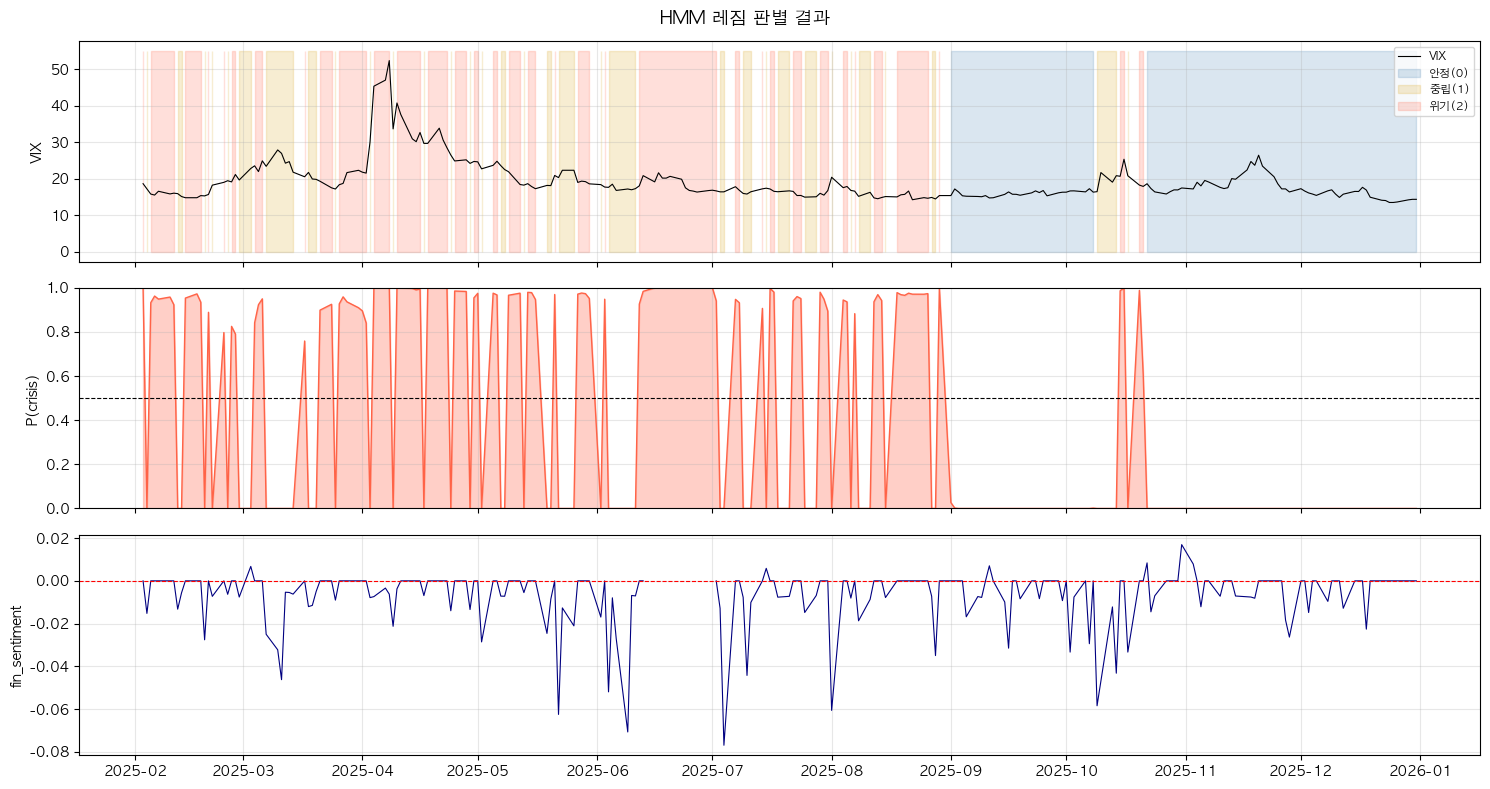

  위기 구간: 2025-02-03 ~ 2025-03-06 (16일)
  위기 구간: 2025-03-17 ~ 2025-05-21 (33일)
  위기 구간: 2025-05-27 ~ 2025-06-03 (5일)
  위기 구간: 2025-06-12 ~ 2025-07-08 (17일)
  위기 구간: 2025-07-14 ~ 2025-08-29 (23일)
  위기 구간: 2025-10-15 ~ 2025-10-21 (4일)


In [21]:
# ── HMM 레짐 시각화 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
fig.suptitle("HMM 레짐 판별 결과", fontsize=13, fontweight='bold')

colors = {0: 'steelblue', 1: 'goldenrod', 2: 'tomato'}
labels = {0: '안정(0)', 1: '중립(1)', 2: '위기(2)'}

# (1) VIX + 레짐 배경색
ax = axes[0]
vix_plot = hmm_input['VIX_level'].reindex(regime_df.index)
ax.plot(vix_plot.index, vix_plot.values, color='black', lw=0.8, label='VIX')
for k, col in colors.items():
    mask = regime_df['hmm_regime'] == k
    ax.fill_between(regime_df.index, 0, vix_plot.max() * 1.05,
                    where=mask, alpha=0.2, color=col, label=labels[k])
ax.set_ylabel('VIX'); ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)

# (2) 위기 확률
ax = axes[1]
ax.plot(regime_df.index, regime_df['hmm_crisis_prob'], color='tomato', lw=1.0)
ax.fill_between(regime_df.index, 0, regime_df['hmm_crisis_prob'], alpha=0.3, color='tomato')
ax.axhline(0.5, color='black', ls='--', lw=0.8)
ax.set_ylabel('P(crisis)'); ax.set_ylim(0, 1); ax.grid(alpha=0.3)

# (3) fin_sentiment
ax = axes[2]
sent_plot = gdelt_daily['fin_sentiment'].reindex(regime_df.index)
ax.plot(sent_plot.index, sent_plot.values, color='navy', lw=0.8)
ax.axhline(0, color='red', ls='--', lw=0.8)
ax.set_ylabel('fin_sentiment'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hmm_regime_viz.png", dpi=150, bbox_inches='tight')
plt.show()

# 위기 레짐 주요 구간 출력
crisis_mask  = regime_df['hmm_regime'] == 2
crisis_dates = regime_df[crisis_mask].index
if len(crisis_dates) > 0:
    # 연속 구간 그루핑
    gaps = (crisis_dates.to_series().diff() > pd.Timedelta('5D')).cumsum()
    for gid, grp in crisis_dates.to_series().groupby(gaps):
        print(f"  위기 구간: {grp.iloc[0].date()} ~ {grp.iloc[-1].date()} ({len(grp)}일)")

## 6. GDELT + HMM 피처를 패널에 통합

GDELT/HMM은 날짜별 값(date-level) → 모든 ticker에 동일하게 broadcast

In [22]:
# ── 날짜 수준 피처 DataFrame 구성 ────────────────────────────────────────────
xgb_gdelt_cols = ['gdelt_avg_tone_1m', 'gdelt_tone_momentum', 'gdelt_article_volume', 'min_shock']
hmm_cols       = ['hmm_crisis_prob', 'hmm_regime']

date_features = (
    gdelt_daily[xgb_gdelt_cols]
    .join(regime_df[hmm_cols], how='outer')
    .ffill()
    .fillna(0)
)

# ── 패널 날짜 인덱스에 align ─────────────────────────────────────────────────
panel_dates = panel.index.get_level_values('date').unique().sort_values()
date_features_aligned = date_features.reindex(panel_dates, method='ffill').fillna(0)

# ── 패널에 merge (date level join) ──────────────────────────────────────────
# MultiIndex (date, ticker) 패널에 date-level 값을 broadcast
panel_enhanced = panel.copy()
for col in date_features_aligned.columns:
    panel_enhanced[col] = (
        panel_enhanced.index
        .get_level_values('date')
        .map(date_features_aligned[col])
    )

print("✅ 패널 통합 완료")
print(f"  기존 컬럼 수: {panel.shape[1]}")
print(f"  추가 컬럼  : {list(date_features_aligned.columns)}")
print(f"  새 컬럼 수 : {panel_enhanced.shape[1]}")

# 통합 확인
print("\n[통합 샘플]")
panel_enhanced[['VIX_level', 'HY_spread'] + list(date_features_aligned.columns)].head(3)

✅ 패널 통합 완료
  기존 컬럼 수: 36
  추가 컬럼  : ['gdelt_avg_tone_1m', 'gdelt_tone_momentum', 'gdelt_article_volume', 'min_shock', 'hmm_crisis_prob', 'hmm_regime']
  새 컬럼 수 : 42

[통합 샘플]


VIX_level  HY_spread  gdelt_avg_tone_1m  \
date       ticker                                            
2017-01-04 AGG         11.85       4.02                0.0   
           DBC         11.85       4.02                0.0   
           EEM         11.85       4.02                0.0   

                   gdelt_tone_momentum  gdelt_article_volume  min_shock  \
date       ticker                                                         
2017-01-04 AGG                     0.0                   0.0        0.0   
           DBC                     0.0                   0.0        0.0   
           EEM                     0.0                   0.0        0.0   

                   hmm_crisis_prob  hmm_regime  
date       ticker                               
2017-01-04 AGG                 0.0         0.0  
           DBC                 0.0         0.0  
           EEM                 0.0         0.0

## 7. 피처 / 타겟 정의

In [23]:
TARGET_COL  = "fwd_ret_21d"
SECTOR_COL  = "asset_class"

# ── 자산별 특성 피처 (11개) ──────────────────────────────────────────────────
ASSET_FEATURES = [
    "ret_1m", "ret_3m", "ret_6m", "ret_12m",
    "vol_21d", "vol_63d", "vol_ratio",
    "beta_60d", "beta_120d",
    "rate_corr_60d", "rsi_14d",
]

# ── 거시 파생 피처 (17개) ────────────────────────────────────────────────────
MACRO_FEATURES = [
    "VIX_level", "VIX_contango", "VIX_slope_9d_3m", "VIX_slope_3m_6m",
    "SKEW_level", "SKEW_zscore",
    "Cu_Au_ratio", "Cu_Au_ratio_chg",
    "HY_spread", "HY_spread_chg",
    "yield_curve", "yield_curve_inv",
    "claims_4wma", "claims_zscore",
    "WEI_level", "sahm_indicator", "DGS10_chg5",
]

# ── GDELT 피처 (3개: GKG 2개 + EVENTS 1개) ──────────────────────────────────
# fin_sentiment/article_count_norm은 HMM에도 투입되고 XGBoost에도 들어감
# min_shock은 EVENTS 기반 이벤트 충격 → XGBoost에만
GDELT_FEATURES = [
    "gdelt_avg_tone_1m",      # GKG: 21일 평균 감성
    "gdelt_tone_momentum",    # GKG: 감성 추세 가속도
    "gdelt_article_volume",   # GKG: 뉴스 볼륨 정규화
    "min_shock",              # EVENTS: 당일 최극단 충격
]

# ── HMM 레짐 피처 (1개) ──────────────────────────────────────────────────────
HMM_FEATURES = ["hmm_crisis_prob"]

# ── 실제 패널에 존재하는 컬럼만 선택 (graceful degradation) ──────────────────
NUM_FEATURES   = ASSET_FEATURES + MACRO_FEATURES + GDELT_FEATURES + HMM_FEATURES
available_num  = [c for c in NUM_FEATURES if c in panel_enhanced.columns]
available_cat  = [SECTOR_COL] if SECTOR_COL in panel_enhanced.columns else []
FINAL_FEATURES = available_num + available_cat

missing_cols = [c for c in NUM_FEATURES if c not in panel_enhanced.columns]

print(f"자산별 특성 피처 : {len([c for c in ASSET_FEATURES if c in panel_enhanced.columns])}개")
print(f"거시 파생 피처   : {len([c for c in MACRO_FEATURES if c in panel_enhanced.columns])}개")
print(f"GDELT 피처       : {len([c for c in GDELT_FEATURES if c in panel_enhanced.columns])}개")
print(f"HMM 피처         : {len([c for c in HMM_FEATURES if c in panel_enhanced.columns])}개")
print(f"카테고리 피처    : {len(available_cat)}개  →  {available_cat}")
print(f"─────────────────────────────────────────────")
print(f"총 피처          : {len(FINAL_FEATURES)}개")
if missing_cols:
    print(f"\n⚠️ 누락 피처: {missing_cols}")

자산별 특성 피처 : 11개
거시 파생 피처   : 17개
GDELT 피처       : 4개
HMM 피처         : 1개
카테고리 피처    : 1개  →  ['asset_class']
─────────────────────────────────────────────
총 피처          : 34개


## 8. Walk-Forward 헬퍼 함수

Step3A와 동일한 로직을 재사용. 변경 사항 없음.

In [24]:
def discretize_labels(is_ret, oos_ret, n_classes=5):
    """IS 수익률 분위수로 bins 계산 → IS/OOS 레이블 반환 (look-ahead bias 없음)"""
    _, bins = pd.qcut(is_ret, q=n_classes, retbins=True, duplicates='drop')
    bins[0]  = -np.inf
    bins[-1] =  np.inf

    def _cut(arr):
        return (pd.Series(
                    pd.cut(arr, bins=bins,
                           labels=list(range(n_classes)),
                           include_lowest=True)
                ).astype(float).fillna(0).astype(int).values)

    is_labels  = _cut(is_ret)
    oos_labels = _cut(oos_ret)
    r_bar      = {k: float(is_ret[is_labels == k].mean())
                  if (is_labels == k).sum() > 0 else 0.0
                  for k in range(n_classes)}
    return is_labels, oos_labels, bins, r_bar


def compute_Q_Omega(proba, r_bar, n_classes=5):
    """
    Q_i     = Σ_k  r̄_k × P(C_k | z_i)
    Omega_i = Σ_k  P(C_k | z_i) × (r̄_k - Q_i)²
    """
    r_arr = np.array([r_bar[k] for k in range(n_classes)])
    Q     = proba @ r_arr
    Omega = np.sum(
        proba * (r_arr[np.newaxis, :] - Q[:, np.newaxis]) ** 2,
        axis=1
    )
    return Q, Omega


def build_X(df, num_cols, cat_col=None):
    """피처 행렬 구성. cat_col은 category dtype으로 추가 (XGBoost enable_categorical용)"""
    X = df[num_cols].fillna(0).copy()
    if cat_col and cat_col in df.columns:
        X[cat_col] = df[cat_col].astype('category')
    return X


def r2_oos(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else np.nan


print("✅ 헬퍼 함수 정의 완료")

✅ 헬퍼 함수 정의 완료


## 9. Optuna 목적함수

In [25]:
def make_objective(X_tr, y_tr, n_classes, val_ratio=0.2, embargo_days=21):
    """
    Optuna objective 팩토리.
    IS를 날짜 기준 80/20 분할 → log_loss 최소화.

    IS=150 기준:
      내부 Train : (129 × 0.8) - 21 = 82일 × 22 ETF ≈ 1,804행
      내부 Val   : 129 × 0.2       = 26일 × 22 ETF ≈  572행
    """
    row_dates    = pd.DatetimeIndex(X_tr.index.get_level_values('date'))
    unique_dates = row_dates.unique().sort_values()
    n_dates      = len(unique_dates)

    val_start_idx  = int(n_dates * (1 - val_ratio))
    train_end_idx  = max(val_start_idx - embargo_days, 1)

    train_cutoff   = unique_dates[train_end_idx - 1]
    val_start_date = unique_dates[val_start_idx]

    train_mask = row_dates <= train_cutoff
    val_mask   = row_dates >= val_start_date

    X_t, X_v = X_tr[train_mask], X_tr[val_mask]
    y_t, y_v = y_tr[train_mask], y_tr[val_mask]

    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 100, 500),
            max_depth         = trial.suggest_int("max_depth", 3, 7),
            learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample         = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
            gamma             = trial.suggest_float("gamma", 0.0, 3.0),
            reg_lambda        = trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
            # 고정값
            objective          = "multi:softprob",
            num_class          = n_classes,
            eval_metric        = "mlogloss",
            tree_method        = "hist",
            enable_categorical = True,
            random_state       = RANDOM_STATE,
            early_stopping_rounds = 20,
            n_jobs             = -1,
            verbosity          = 0,
        )
        model = XGBClassifier(**params)
        model.fit(X_t, y_t, eval_set=[(X_v, y_v)], verbose=False)
        proba_v = model.predict_proba(X_v)
        # labels 명시: val set에 특정 quintile 없어도 5-class log_loss 계산 가능
        return log_loss(y_v, proba_v, labels=list(range(n_classes)))

    return objective


print("✅ Optuna objective 정의 완료")

✅ Optuna objective 정의 완료


## 10. Walk-Forward 날짜 윈도우 생성

In [26]:
dates_arr = (
    panel_enhanced.index
    .get_level_values('date')
    .unique()
    .sort_values()
    .to_numpy()
)
n_dates = len(dates_arr)

windows = []
i = 0
while True:
    oos_end = i + IS_DAYS + EMBARGO_DAYS + OOS_DAYS
    if oos_end > n_dates:
        break
    windows.append({
        'window_id'      : len(windows),
        'is_dates'       : dates_arr[i : i + IS_DAYS],
        'emb_dates'      : dates_arr[i + IS_DAYS : i + IS_DAYS + EMBARGO_DAYS],
        'oos_dates'      : dates_arr[i + IS_DAYS + EMBARGO_DAYS : oos_end],
        'oos_start_date' : dates_arr[i + IS_DAYS + EMBARGO_DAYS],
        'oos_end_date'   : dates_arr[oos_end - 1],
    })
    i += OOS_DAYS

print(f"총 날짜 수  : {n_dates}")
print(f"총 윈도우 수: {len(windows)}")
for w in windows[:3]:
    print(f"  W{w['window_id']:02d}: IS {w['is_dates'][0]!s:.10s}~{w['is_dates'][-1]!s:.10s} "
          f"| OOS {w['oos_start_date']!s:.10s}~{w['oos_end_date']!s:.10s}")
print("  ...")

총 날짜 수  : 2346
총 윈도우 수: 103
  W00: IS 2017-01-04~2017-08-01 | OOS 2017-08-31~2017-09-28
  W01: IS 2017-02-02~2017-08-30 | OOS 2017-09-29~2017-10-27
  W02: IS 2017-03-03~2017-09-28 | OOS 2017-10-30~2017-11-27
  ...


## 11. Walk-Forward 메인 루프

각 윈도우:
1. IS / OOS 분할 + Purge (IS 마지막 21일 제거)
2. IS 기준 5분위 이산화 + r̄_k 계산
3. Optuna 하이퍼파라미터 탐색 (IS 내부 80/20)
4. 전체 IS로 최종 XGBoost 학습
5. OOS 확률 예측 → Q, Ω 계산

In [27]:
all_results     = []
window_stats    = []
best_params_log = []
final_model     = None

dates_level_idx = panel_enhanced.index.get_level_values('date')
cat_col = available_cat[0] if available_cat else None

for window in tqdm(windows, desc="Walk-Forward (GDELT+HMM)"):
    wid = window['window_id']

    # ── 1. IS / OOS 슬라이싱 ────────────────────────────────────────────────
    is_dates_idx  = pd.DatetimeIndex(window['is_dates'])
    oos_dates_idx = pd.DatetimeIndex(window['oos_dates'])

    is_df  = panel_enhanced[dates_level_idx.isin(is_dates_idx)].copy()
    oos_df = panel_enhanced[dates_level_idx.isin(oos_dates_idx)].copy()

    is_df       = is_df.dropna(subset=[TARGET_COL])
    oos_pred_df = oos_df.dropna(subset=available_num)
    oos_eval_df = oos_df.dropna(subset=[TARGET_COL])

    # ── Purge: IS 마지막 OOS_DAYS 거래일 제거 (label leakage 방지) ───────────
    is_unique_dates = pd.DatetimeIndex(
        is_df.index.get_level_values('date').unique()
    ).sort_values()
    if len(is_unique_dates) > OOS_DAYS:
        purge_cutoff = is_unique_dates[-OOS_DAYS]
        is_df = is_df[
            pd.DatetimeIndex(is_df.index.get_level_values('date')) < purge_cutoff
        ]

    if len(is_df) < IS_DAYS // 2 or len(oos_pred_df) == 0:
        continue

    # ── 2. 5분위 이산화 ─────────────────────────────────────────────────────
    is_ret = is_df[TARGET_COL].values
    try:
        is_labels, _, bins, r_bar = discretize_labels(
            is_ret, np.zeros(len(oos_pred_df)), n_classes=N_CLASSES
        )
    except Exception as e:
        continue

    # ── 3. 피처 행렬 ────────────────────────────────────────────────────────
    X_is  = build_X(is_df, available_num, cat_col)
    X_oos = build_X(oos_pred_df, available_num, cat_col)
    y_is  = is_labels

    # ── 4. Optuna 탐색 ───────────────────────────────────────────────────────
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + wid),
    )
    study.optimize(
        make_objective(X_is, y_is, N_CLASSES, embargo_days=EMBARGO_DAYS),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=False
    )

    best_p = study.best_params.copy()
    best_p.update({
        'objective'         : 'multi:softprob',
        'num_class'         : N_CLASSES,
        'eval_metric'       : 'mlogloss',
        'tree_method'       : 'hist',
        'enable_categorical': True,
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
        'verbosity'         : 0,
    })
    best_params_log.append({'window_id': wid, **best_p})

    # ── 5. 전체 IS로 최종 학습 ───────────────────────────────────────────────
    final_model = XGBClassifier(**best_p)
    final_model.fit(X_is, y_is, verbose=False)

    # ── 6. OOS 예측 → Q, Ω ──────────────────────────────────────────────────
    proba_oos         = final_model.predict_proba(X_oos)
    Q_arr, Omega_arr  = compute_Q_Omega(proba_oos, r_bar, N_CLASSES)

    # ── 7. 평가 ──────────────────────────────────────────────────────────────
    acc = r2 = np.nan
    if len(oos_eval_df) > 0:
        pred_idx = oos_pred_df.index
        eval_idx = oos_eval_df.index
        common   = pred_idx.intersection(eval_idx)
        if len(common) > 0:
            pred_pos = {idx: pos for pos, idx in enumerate(pred_idx)}
            eval_pos = {idx: pos for pos, idx in enumerate(eval_idx)}
            pp = [pred_pos[i] for i in common]
            ep = [eval_pos[i] for i in common]
            _, oos_lbl, _, _ = discretize_labels(
                is_ret,
                oos_eval_df.iloc[ep][TARGET_COL].values,
                n_classes=N_CLASSES
            )
            acc = accuracy_score(oos_lbl, final_model.predict(X_oos.iloc[pp]))
            r2  = r2_oos(oos_eval_df.iloc[ep][TARGET_COL].values, Q_arr[pp])

    # ── 8. 행별 결과 저장 ────────────────────────────────────────────────────
    eval_ret_map = {idx: oos_eval_df.iloc[i][TARGET_COL]
                    for i, idx in enumerate(oos_eval_df.index)}

    for i, idx in enumerate(oos_pred_df.index):
        row = {
            'date'      : idx[0],
            'ticker'    : idx[1],
            'Q'         : Q_arr[i],
            'Omega'     : Omega_arr[i],
            'actual_ret': eval_ret_map.get(idx, np.nan),
            'window_id' : wid,
            # 레짐 정보 (분석용)
            'hmm_crisis_prob': oos_pred_df.iloc[i].get('hmm_crisis_prob', np.nan)
                               if 'hmm_crisis_prob' in oos_pred_df.columns else np.nan,
        }
        for c in range(N_CLASSES):
            row[f'proba_C{c+1}'] = float(proba_oos[i, c])
        all_results.append(row)

    window_stats.append({
        'window_id'          : wid,
        'oos_start'          : window['oos_start_date'],
        'oos_end'            : window['oos_end_date'],
        'is_size'            : len(is_df),
        'oos_size'           : len(oos_pred_df),
        'oos_accuracy'       : acc,
        'oos_r2'             : r2,
        'optuna_best_logloss': study.best_value,
        'r_bar_C1'           : r_bar[0],
        'r_bar_C5'           : r_bar[4],
    })

print(f"\n✅ Walk-Forward 완료: {len(window_stats)}개 윈도우")

Walk-Forward (GDELT+HMM):   0%|          | 0/103 [00:00<?, ?it/s]


✅ Walk-Forward 완료: 103개 윈도우


## 12. 결과 집계 및 저장

In [28]:
results_df = (
    pd.DataFrame(all_results)
    .set_index(['date', 'ticker'])
    .sort_index()
)
stats_df  = pd.DataFrame(window_stats)
params_df = pd.DataFrame(best_params_log)

results_df.to_parquet(OUTPUT_DIR / "xgb_gdelt_hmm_Q_Omega.parquet")
stats_df.to_csv(OUTPUT_DIR / "xgb_gdelt_hmm_window_stats.csv", index=False)
params_df.to_csv(OUTPUT_DIR / "xgb_gdelt_hmm_best_params.csv", index=False)

print(f"xgb_gdelt_hmm_Q_Omega.parquet     → shape {results_df.shape}")
print(f"xgb_gdelt_hmm_window_stats.csv    → shape {stats_df.shape}")
print(f"xgb_gdelt_hmm_best_params.csv     → shape {params_df.shape}")
print(f"저장 위치: {OUTPUT_DIR.resolve()}")

xgb_gdelt_hmm_Q_Omega.parquet     → shape (47582, 10)
xgb_gdelt_hmm_window_stats.csv    → shape (103, 10)
xgb_gdelt_hmm_best_params.csv     → shape (103, 18)
저장 위치: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/outputs/step3b


## 13. OOS 성과 요약 (Step3A 베이스라인과 비교)

In [29]:
print("=" * 60)
print("  XGBoost Walk-Forward OOS 성과 (GDELT + HMM 추가)")
print("=" * 60)

acc_s = stats_df['oos_accuracy'].dropna()
r2_s  = stats_df['oos_r2'].dropna()

print(f"\n[5분위 분류 Accuracy]")
print(f"  평균   : {acc_s.mean():.4f}  (랜덤 기준선: {1/N_CLASSES:.4f})")
print(f"  중앙값 : {acc_s.median():.4f}")
print(f"  std    : {acc_s.std():.4f}")
print(f"  범위   : {acc_s.min():.4f} ~ {acc_s.max():.4f}")

print(f"\n[R²_oos  (Q vs 실제수익률)]")
print(f"  평균         : {r2_s.mean():.4f}")
print(f"  R²>0 비율    : {(r2_s>0).mean():.1%}")

print(f"\n[Q / Ω 분포]")
print(f"  Q   평균: {results_df['Q'].mean():.5f}  std: {results_df['Q'].std():.5f}")
print(f"  Ω   평균: {results_df['Omega'].mean():.6f}  std: {results_df['Omega'].std():.6f}")

# Step3A 베이스라인 비교 (저장된 stats 파일이 있는 경우)
baseline_path = Path("outputs/step3/xgb_window_stats.csv")
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    b_acc = baseline['oos_accuracy'].dropna().mean()
    b_r2  = (baseline['oos_r2'].dropna() > 0).mean()
    print(f"\n[Step3A 베이스라인 대비]")
    print(f"  Accuracy  베이스라인 {b_acc:.4f}  →  현재 {acc_s.mean():.4f}  "
          f"({'↑' if acc_s.mean() > b_acc else '↓'} {abs(acc_s.mean()-b_acc):.4f})")
    print(f"  R²>0 비율 베이스라인 {b_r2:.1%}  →  현재 {(r2_s>0).mean():.1%}  "
          f"({'↑' if (r2_s>0).mean() > b_r2 else '↓'})")

  XGBoost Walk-Forward OOS 성과 (GDELT + HMM 추가)

[5분위 분류 Accuracy]
  평균   : 0.2741  (랜덤 기준선: 0.2000)
  중앙값 : 0.2771
  std    : 0.1028
  범위   : 0.0671 ~ 0.6212

[R²_oos  (Q vs 실제수익률)]
  평균         : -0.8651
  R²>0 비율    : 10.7%

[Q / Ω 분포]
  Q   평균: 0.00221  std: 0.02800
  Ω   평균: 0.001344  std: 0.001886

[Step3A 베이스라인 대비]
  Accuracy  베이스라인 0.2701  →  현재 0.2741  (↑ 0.0040)
  R²>0 비율 베이스라인 13.6%  →  현재 10.7%  (↓)


## 14. Cross-Sectional IC (Information Coefficient)

Black-Litterman 관점에서 R²_oos보다 IC가 더 중요한 성과 지표.  
같은 날짜에서 Q가 높은 ETF가 실제로 더 올랐는가(서열 일치)를 측정.

In [30]:
def calc_ic(g):
    df = g.dropna(subset=['Q', 'actual_ret'])
    if len(df) < 5:
        return np.nan
    return spearmanr(df['Q'], df['actual_ret'])[0]

ic_series = (
    results_df
    .groupby(level='date')
    .apply(calc_ic)
    .rename('IC')
    .dropna()
)

ic_mean = ic_series.mean()
ic_std  = ic_series.std()
icir    = ic_mean / ic_std if ic_std > 1e-12 else np.nan
ic_pos  = (ic_series > 0).mean()

print("=" * 50)
print("  Cross-Sectional IC (GDELT + HMM 추가)")
print("=" * 50)
print(f"  IC 평균  : {ic_mean:.4f}  (0.05↑ 유의미)")
print(f"  IC std   : {ic_std:.4f}")
print(f"  ICIR     : {icir:.4f}   (0.5↑ 양호, 1.0↑ 우수)")
print(f"  IC > 0   : {ic_pos:.1%}  (50%↑ 양호)")

if icir > 1.0:
    print("\n  판정: 우수한 크로스섹션 신호 ✅")
elif icir > 0.5:
    print("\n  판정: 양호한 크로스섹션 신호 — BL 활용 가능 ✅")
elif ic_mean > 0:
    print("\n  판정: 약한 신호 — BL tau 작게 설정 권장")
else:
    print("\n  판정: 신호 없음 — 피처 재검토 필요")

# ── 레짐별 IC 분해 ────────────────────────────────────────────────────────────
if 'hmm_crisis_prob' in results_df.columns:
    # hmm_crisis_prob를 날짜별로 매핑 (ticker마다 같으므로 첫 ticker 기준)
    regime_by_date = (
        results_df['hmm_crisis_prob']
        .groupby(level='date').first()
    )
    ic_with_regime = ic_series.to_frame().join(regime_by_date.rename('crisis_prob'))
    ic_stable = ic_with_regime[ic_with_regime['crisis_prob'] < 0.3]['IC'].mean()
    ic_crisis = ic_with_regime[ic_with_regime['crisis_prob'] > 0.6]['IC'].mean()
    print(f"\n  레짐별 IC:")
    print(f"    안정 레짐(crisis_prob<0.3) : IC={ic_stable:.4f}")
    print(f"    위기 레짐(crisis_prob>0.6) : IC={ic_crisis:.4f}")
    print("    (위기 레짐 IC가 낮으면 → 위기 구간에서 예측이 어려운 것은 정상적)")

  Cross-Sectional IC (GDELT + HMM 추가)
  IC 평균  : 0.0025  (0.05↑ 유의미)
  IC std   : 0.3562
  ICIR     : 0.0072   (0.5↑ 양호, 1.0↑ 우수)
  IC > 0   : 49.4%  (50%↑ 양호)

  판정: 약한 신호 — BL tau 작게 설정 권장

  레짐별 IC:
    안정 레짐(crisis_prob<0.3) : IC=0.0060
    위기 레짐(crisis_prob>0.6) : IC=-0.0708
    (위기 레짐 IC가 낮으면 → 위기 구간에서 예측이 어려운 것은 정상적)


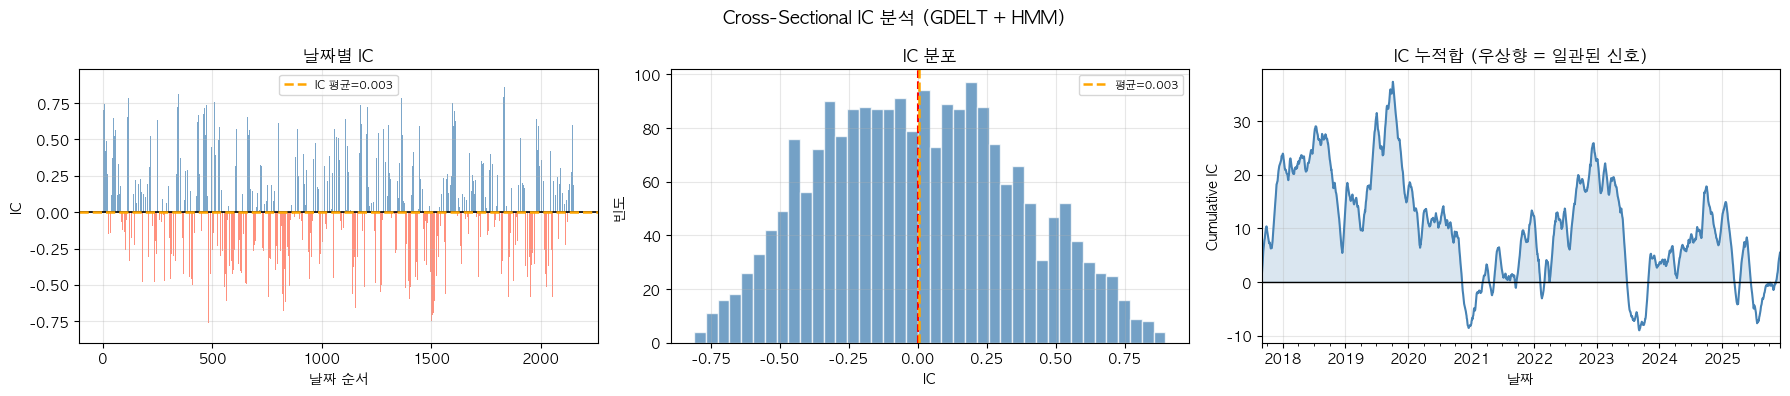

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cross-Sectional IC 분석 (GDELT + HMM)", fontsize=13, fontweight='bold')

# (1) 날짜별 IC 바 차트
ax = axes[0]
colors_ic = ['steelblue' if v > 0 else 'tomato' for v in ic_series.values]
ax.bar(range(len(ic_series)), ic_series.values, color=colors_ic, alpha=0.7)
ax.axhline(0,       color='black',  lw=1.2)
ax.axhline(ic_mean, color='orange', lw=1.8, ls='--', label=f'IC 평균={ic_mean:.3f}')
ax.set_title('날짜별 IC'); ax.set_xlabel('날짜 순서'); ax.set_ylabel('IC')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (2) IC 분포
ax = axes[1]
ax.hist(ic_series.values, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(0,       color='red',    lw=1.5, ls='--')
ax.axvline(ic_mean, color='orange', lw=1.8, ls='--', label=f'평균={ic_mean:.3f}')
ax.set_title('IC 분포'); ax.set_xlabel('IC'); ax.set_ylabel('빈도')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (3) IC 누적합
ax = axes[2]
ic_cum = ic_series.cumsum()
ic_cum.plot(ax=ax, color='steelblue', lw=1.5)
ax.fill_between(ic_series.index, ic_cum, 0,
                where=(ic_cum > 0), alpha=0.2, color='steelblue')
ax.axhline(0, color='black', lw=1)
ax.set_title('IC 누적합 (우상향 = 일관된 신호)')
ax.set_xlabel('날짜'); ax.set_ylabel('Cumulative IC'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ic_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## 15. 성과 시각화

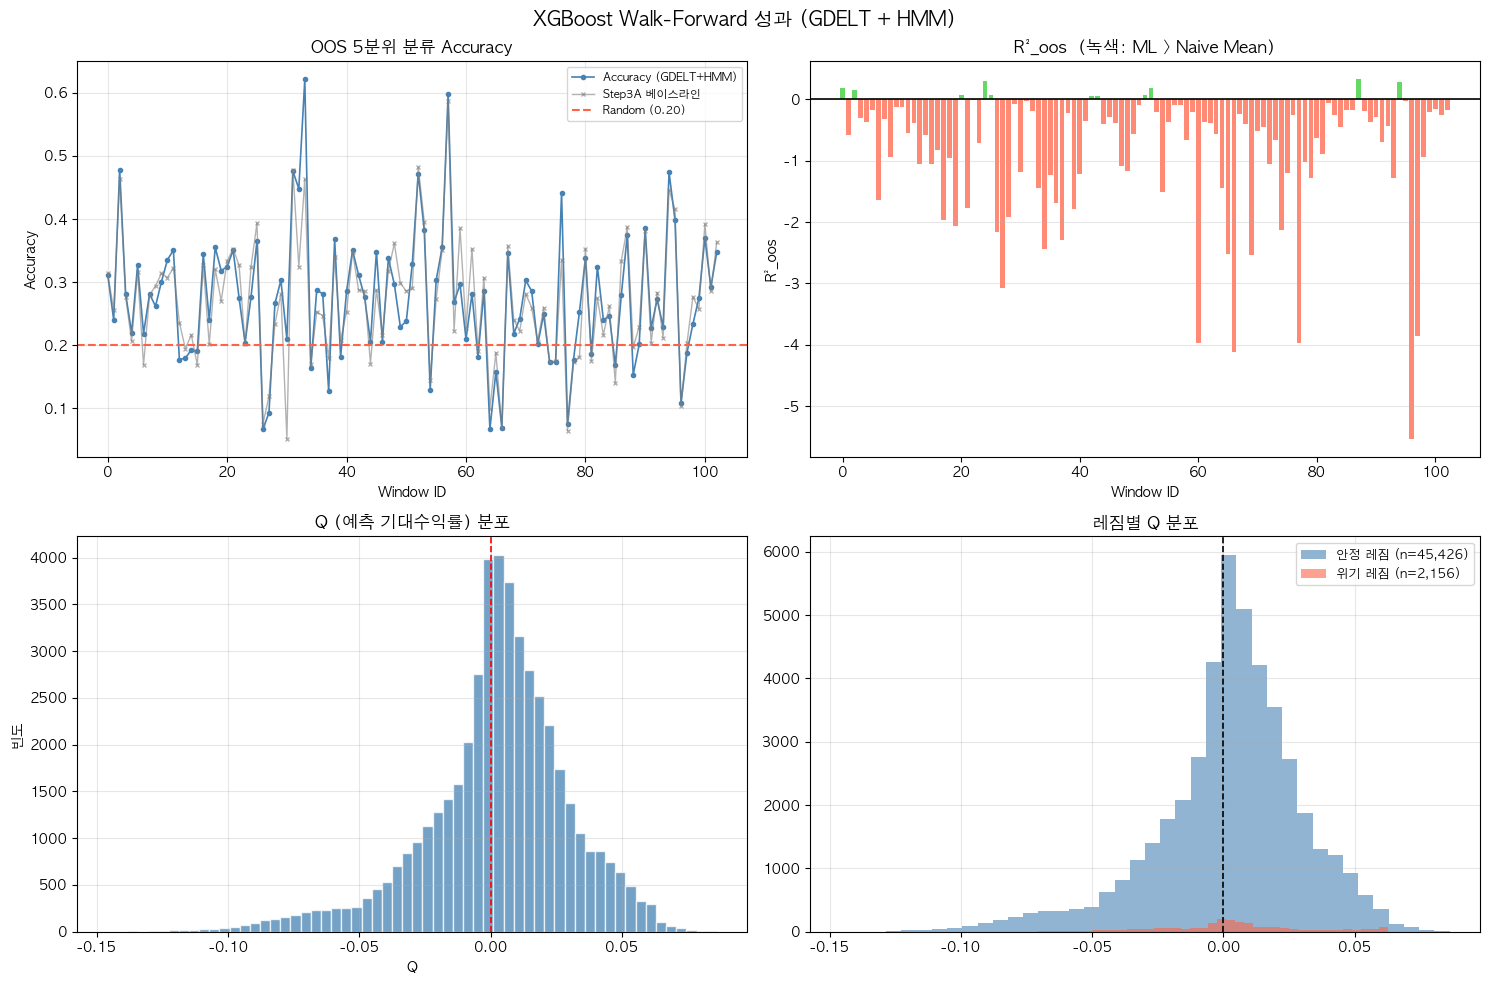

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("XGBoost Walk-Forward 성과 (GDELT + HMM)", fontsize=14, fontweight='bold')

# (1) OOS Accuracy by Window
ax = axes[0, 0]
ax.plot(stats_df['window_id'], stats_df['oos_accuracy'],
        marker='o', ms=3, lw=1.2, color='steelblue', label='Accuracy (GDELT+HMM)')
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    ax.plot(baseline['window_id'], baseline['oos_accuracy'],
            marker='x', ms=3, lw=1.0, color='gray', alpha=0.6, label='Step3A 베이스라인')
ax.axhline(1/N_CLASSES, color='tomato', ls='--', lw=1.5, label=f'Random (0.{int(100/N_CLASSES):02d})')
ax.set_title('OOS 5분위 분류 Accuracy'); ax.set_xlabel('Window ID')
ax.set_ylabel('Accuracy'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (2) R²_oos
ax = axes[0, 1]
c_bar = ['limegreen' if v > 0 else 'tomato' for v in stats_df['oos_r2'].fillna(0)]
ax.bar(stats_df['window_id'], stats_df['oos_r2'].fillna(0), color=c_bar, alpha=0.75)
ax.axhline(0, color='black', lw=1.2)
ax.set_title('R²_oos  (녹색: ML > Naive Mean)'); ax.set_xlabel('Window ID')
ax.set_ylabel('R²_oos'); ax.grid(alpha=0.3, axis='y')

# (3) Q 분포
ax = axes[1, 0]
ax.hist(results_df['Q'], bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(0, color='red', ls='--', lw=1.2)
ax.set_title('Q (예측 기대수익률) 분포')
ax.set_xlabel('Q'); ax.set_ylabel('빈도'); ax.grid(alpha=0.3)

# (4) 레짐별 Q 분포
ax = axes[1, 1]
if 'hmm_crisis_prob' in results_df.columns:
    stable_q = results_df[results_df['hmm_crisis_prob'] < 0.3]['Q']
    crisis_q = results_df[results_df['hmm_crisis_prob'] > 0.6]['Q']
    ax.hist(stable_q, bins=40, alpha=0.6, color='steelblue', label=f'안정 레짐 (n={len(stable_q):,})')
    ax.hist(crisis_q, bins=40, alpha=0.6, color='tomato',    label=f'위기 레짐 (n={len(crisis_q):,})')
    ax.axvline(0, color='black', ls='--', lw=1.2)
    ax.set_title('레짐별 Q 분포')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
else:
    ax.text(0.5, 0.5, 'HMM 피처 없음', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "walkforward_performance.png", dpi=150, bbox_inches='tight')
plt.show()

## 16. 피처 중요도 (마지막 윈도우)

GDELT/HMM 피처가 XGBoost에서 실제로 활용되는지 확인.

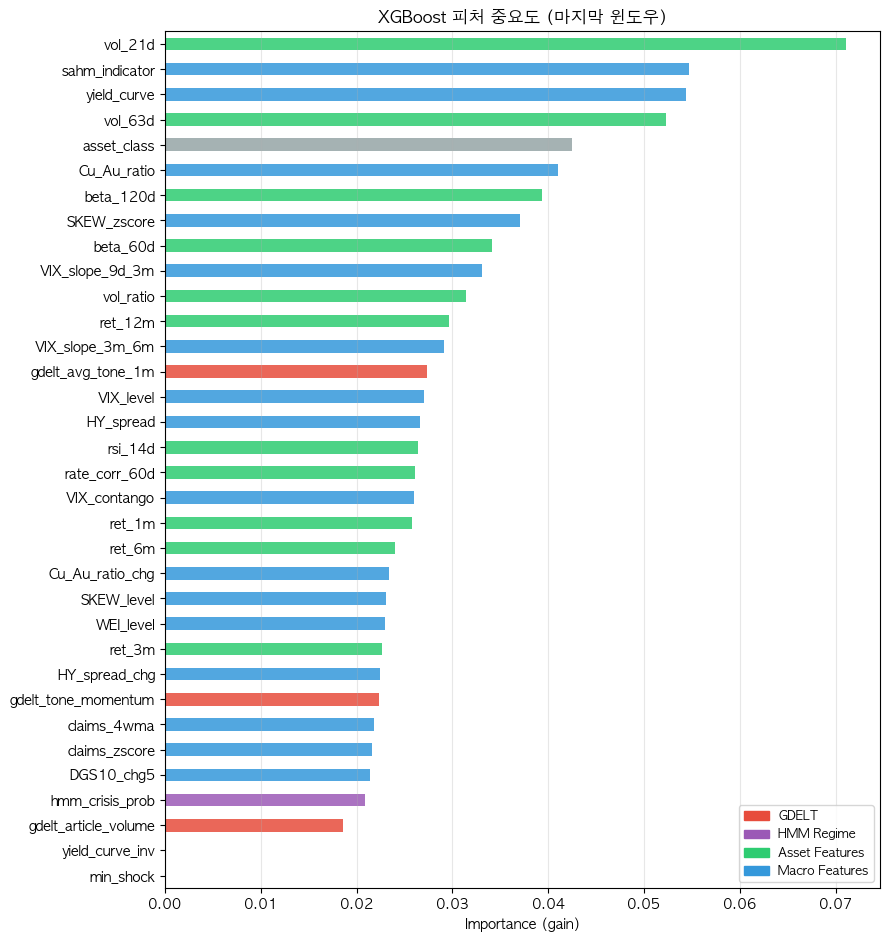


[상위 10 피처]
  [ASSET] vol_21d                   0.07107
  [MACRO] sahm_indicator            0.05466
  [MACRO] yield_curve               0.05438
  [ASSET] vol_63d                   0.05228
  [MACRO] asset_class               0.04246
  [MACRO] Cu_Au_ratio               0.04103
  [ASSET] beta_120d                 0.03932
  [MACRO] SKEW_zscore               0.03703
  [ASSET] beta_60d                  0.03414
  [MACRO] VIX_slope_9d_3m           0.03310

  GDELT + HMM 합산 기여도: 8.9% (전체 피처 대비)


In [33]:
if final_model is not None:
    feat_names = list(final_model.feature_names_in_)
    importance = (
        pd.Series(final_model.feature_importances_, index=feat_names)
        .sort_values(ascending=True)
    )

    # 피처 그룹 색상 구분
    def get_color(name):
        if name in GDELT_FEATURES:
            return '#e74c3c'    # 빨강: GDELT
        elif name in HMM_FEATURES:
            return '#9b59b6'    # 보라: HMM
        elif name in ASSET_FEATURES:
            return '#2ecc71'    # 초록: 자산별 특성
        elif name in MACRO_FEATURES:
            return '#3498db'    # 파랑: 거시지표
        else:
            return '#95a5a6'    # 회색: 기타

    colors_bar = [get_color(n) for n in importance.index]

    fig, ax = plt.subplots(figsize=(9, max(6, len(feat_names) * 0.28)))
    importance.plot(kind='barh', ax=ax, color=colors_bar, alpha=0.85)
    ax.set_title(f'XGBoost 피처 중요도 (마지막 윈도우)', fontsize=12)
    ax.set_xlabel('Importance (gain)')

    # 범례
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(color='#e74c3c', label='GDELT'),
        Patch(color='#9b59b6', label='HMM Regime'),
        Patch(color='#2ecc71', label='Asset Features'),
        Patch(color='#3498db', label='Macro Features'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\n[상위 10 피처]")
    top10 = importance.sort_values(ascending=False).head(10)
    for name, val in top10.items():
        group = ('GDELT' if name in GDELT_FEATURES
                 else 'HMM' if name in HMM_FEATURES
                 else 'ASSET' if name in ASSET_FEATURES
                 else 'MACRO')
        print(f"  [{group:5s}] {name:<25s} {val:.5f}")

    # GDELT + HMM 합산 기여도
    new_feat_imp = importance[[c for c in GDELT_FEATURES + HMM_FEATURES if c in importance.index]].sum()
    total_imp    = importance.sum()
    print(f"\n  GDELT + HMM 합산 기여도: {new_feat_imp/total_imp:.1%} (전체 피처 대비)")

## 17. Black-Litterman 입력용 Q, Ω 최종 저장

Step4에서 직접 로드할 수 있도록 `(date × ticker)` 피벗 형태로 저장.

In [34]:
Q_bl     = results_df['Q'].unstack('ticker')
Omega_bl = results_df['Omega'].unstack('ticker')

Q_bl.to_parquet(OUTPUT_DIR / "Q_xgb_gdelt_hmm.parquet")
Omega_bl.to_parquet(OUTPUT_DIR / "Omega_xgb_gdelt_hmm.parquet")

print("=" * 55)
print("✅ BL 입력 파일 저장 완료 (GDELT + HMM 버전)")
print(f"  Q_xgb_gdelt_hmm.parquet     shape: {Q_bl.shape}")
print(f"  Omega_xgb_gdelt_hmm.parquet shape: {Omega_bl.shape}")
print(f"  저장 위치: {OUTPUT_DIR.resolve()}")
print()
print("[Q 마지막 3 날짜 샘플]")
Q_bl.tail(3)

✅ BL 입력 파일 저장 완료 (GDELT + HMM 버전)
  Q_xgb_gdelt_hmm.parquet     shape: (2163, 22)
  Omega_xgb_gdelt_hmm.parquet shape: (2163, 22)
  저장 위치: /Users/yoonseokim/2025_main_bootcamp/4th_final_project/finance_project/김윤서/outputs/step3b

[Q 마지막 3 날짜 샘플]


ticker,AGG,DBC,EEM,EFA,GLD,IWM,QQQ,SHY,SPY,TIP,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
date,,,,,,,,,,,,,,,,,,,,,
2025-12-11,0.004979,0.010286,0.025240,0.015631,0.012762,0.027961,0.044119,0.003517,0.02821,0.005229,...,-0.003715,0.004341,0.001870,0.012318,0.047661,0.001068,0.012802,0.028359,0.023732,0.030894
2025-12-12,0.004928,0.015306,0.030210,0.018527,0.007702,0.029678,0.037904,0.003545,0.03068,0.005351,...,0.000800,0.012835,0.008036,0.016612,0.043219,-0.001555,0.018783,0.034671,0.026699,0.027926
2025-12-15,0.004725,0.009070,0.025439,0.010086,0.002252,0.029354,0.036082,0.003449,0.02987,0.004829,...,-0.004958,0.003339,-0.008078,0.008379,0.038153,-0.006787,0.013591,0.026698,0.011677,0.014426


## 18. 다음 단계

| 파일 | 내용 |
|------|------|
| `outputs/step3b/Q_xgb_gdelt_hmm.parquet` | BL 입력 Q (date × ticker) |
| `outputs/step3b/Omega_xgb_gdelt_hmm.parquet` | BL 입력 Ω (date × ticker) |
| `data/hmm_regime.parquet` | 날짜별 레짐 시퀀스 + 확률 |
| `data/gdelt_gkg_cache.parquet` | GKG 캐시 (재수집 불필요) |
| `data/gdelt_events_cache.parquet` | EVENTS 캐시 (재수집 불필요) |

### 모델 선택 (Step3-2)

```
Step3A (베이스라인)  →  OOS Accuracy: 0.2701, ICIR: ??
Step3B (GDELT+HMM)  →  OOS Accuracy: ??,     ICIR: ??
```

Diebold-Mariano 검정으로 두 모델 OOS 성과를 비교한 뒤 우수한 모델의 Q, Ω를 Step4 Black-Litterman에 투입한다.

> **체크리스트**
> - [ ] GDELT BigQuery 쿼리 최초 1회 실행 → `data/gdelt_gkg_cache.parquet` 생성
> - [ ] HMM 학습 완료 → `data/hmm_regime.parquet` 생성
> - [ ] Step3B IC ≥ Step3A IC 확인
> - [ ] `FORCE_REBUILD = False` 유지 (재실행 시 BigQuery 호출 없음)